In [1]:
# First we will Import the libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots 
%matplotlib inline

In [2]:
# Next, we will load the marketing campaign dataset

df = pd.read_csv(
    r"C:\Users\Admin\Desktop\Marketing Performance Analytics\marketing_campaign.csv",
    sep="\t"
)

# Display the first five rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
#Step 3: Understand the Dataset
# Check the number of rows and columns

df.shape

#Observation:This shows the total number of customer records and available features in the dataset.


(2240, 29)

In [4]:
#Step 4: Data Quality Check
# Check for missing values

df.isnull().sum()

#Observation:Identifying missing values helps ensure the dataset is ready for accurate analysis.

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
# Display all column names

print(df.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [6]:
#Step 5: Feature Engineering
# Create the Age column

df["Age"] = 2026 - df["Year_Birth"]
# Calculate the total amount spent by each customer

df["Total_Spend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)
# Calculate the total number of purchases

df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

#Observation:These new features simplify the analysis by combining multiple columns into meaningful business metrics.

In [7]:
# Categorize customers based on their total spending

df["Customer_Segment"] = pd.cut(
    df["Total_Spend"],
    bins=[0, 500, 1500, df["Total_Spend"].max()],
    labels=["Low Value", "Medium Value", "High Value"]
)

In [8]:
# Preview the updated dataset

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spend,Total_Purchases,Customer_Segment
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,3,11,1,69,1617,22,High Value
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,3,11,0,72,27,4,Low Value
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,3,11,0,61,776,20,Medium Value
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,3,11,0,42,53,6,Low Value
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,3,11,0,45,422,14,Low Value


In [9]:
#Step 6: Statistical Analysis
#After preparing the dataset, I will perform statistical analysis to better understand the distribution and characteristics of customer data before moving to advanced visualizations.

#6.1 Summary Statistics
# Display statistical summary for important numerical features

df[["Income","Age","Total_Spend","Total_Purchases"]].describe()

#Observation
#This summary provides information such as mean, median, minimum, maximum, and quartiles, helping us understand customer spending and purchasing patterns.

,Income,Age,Total_Spend,Total_Purchases
count,2216.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,57.194196,605.798214,12.537054
std,25173.076661,11.984069,602.249288,7.205741
min,1730.000000,30.000000,5.000000,0.000000
25%,35303.000000,49.000000,68.750000,6.000000
50%,51381.500000,56.000000,396.000000,12.000000
75%,68522.000000,67.000000,1045.500000,18.000000
max,666666.000000,133.000000,2525.000000,32.000000


In [10]:
#6.2 Median
# Calculate the median values

df[["Income","Total_Spend","Total_Purchases"]].median()

#Observation:The median represents the middle value and is less affected by extreme values than the average.

#6.3 Mode
# Find the most frequently occurring values

df[["Education","Marital_Status"]].mode()


#6.4 Variance & Standard Deviation
# Measure the variability of numerical features

df[["Income","Total_Spend","Total_Purchases"]].agg(["var","std"])

#6.5 Skewness
# Check whether numerical data is normally distributed

df[["Income","Total_Spend"]].skew()

#Insight:Positive skewness indicates that a small number of customers have significantly higher income or spending than the majority.

Income         6.763487
Total_Spend    0.860841
dtype: float64

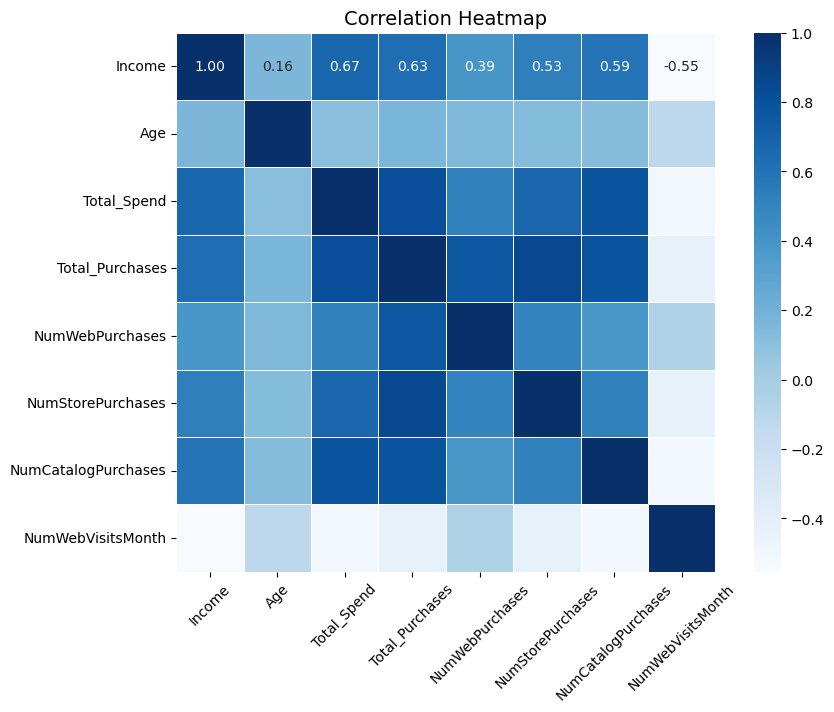

In [11]:
#Step 7: Correlation Analysis
#Next, I will explore relationships between important numerical variables.

# Calculate the correlation matrix

corr = df[["Income","Age","Total_Spend","Total_Purchases",
           "NumWebPurchases","NumStorePurchases",
           "NumCatalogPurchases","NumWebVisitsMonth"]].corr()

corr

#Correlation Heatmap
# Visualize correlations using a heatmap

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

#Business Insight:Strong positive correlations indicate variables that increase together, while negative correlations highlight inverse relationships.

In [32]:
#Step 8: Outlier Detection
Q1 = df["Total_Spend"].quantile(0.25)
Q3 = df["Total_Spend"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Total_Spend"] < lower) |
    (df["Total_Spend"] > upper)
]

print("Number of Spending Outliers:", len(outliers))

outliers[["ID","Income","Total_Spend"]].head()

Number of Spending Outliers: 3


,ID,Income,Total_Spend
1179,5735,90638.0,2525
1492,1763,87679.0,2524
1572,5350,90638.0,2525


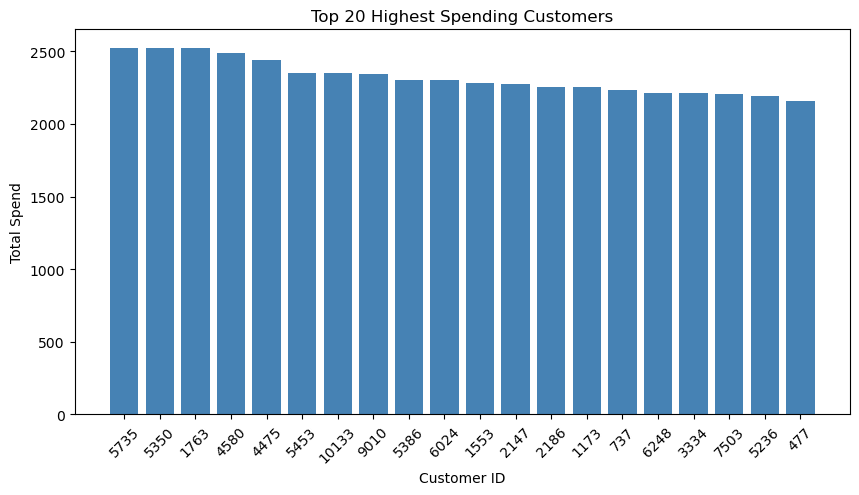

In [33]:
# Outlier:High Spending Customer Analysis

top_spenders = (
    df.nlargest(20, "Total_Spend")
    [["ID", "Total_Spend"]]
)

plt.figure(figsize=(10,5))

plt.bar(
    top_spenders["ID"].astype(str),
    top_spenders["Total_Spend"],
    color="steelblue"
)

plt.title("Top 20 Highest Spending Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")

plt.xticks(rotation=45)

plt.show()

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


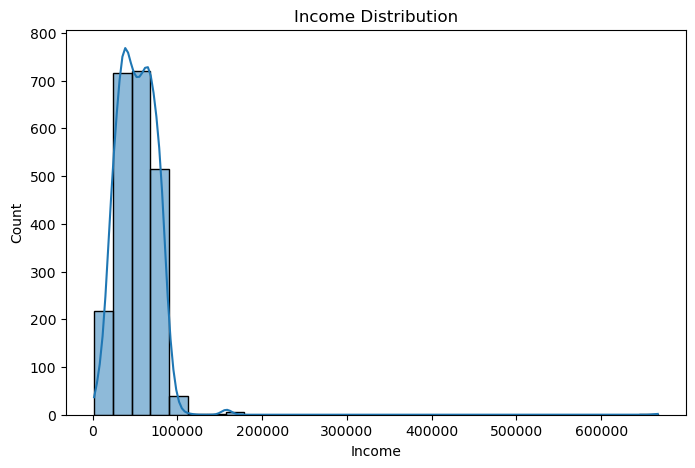

In [14]:
#Step 9: Distribution Analysis
# Analyze customer income distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Income"],
             bins=30,
             kde=True)

plt.title("Income Distribution")

plt.show()

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


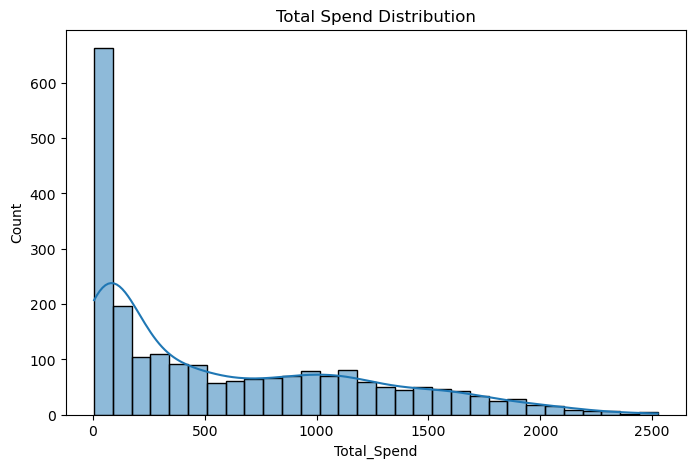

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


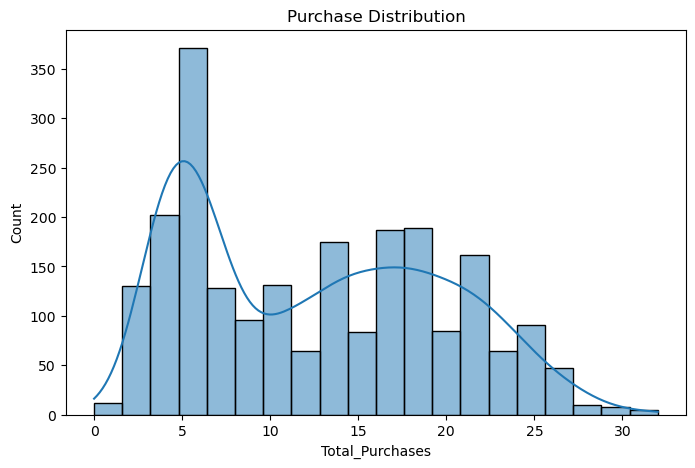

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2822726367.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")[["Age",
C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2822726367.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_products = df.groupby("Customer_Segment")[[


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Customer_Segment,,,,,,
Low Value,70.588283,6.495987,31.725522,9.597913,6.691814,20.129213
Medium Value,500.788770,45.445187,250.113636,64.098930,47.415775,72.613636
High Value,887.288618,68.414634,598.995935,98.178862,68.357724,78.101626


In [15]:
#Total Spend
# Analyze total spending distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Total_Spend"],
             bins=30,
             kde=True)

plt.title("Total Spend Distribution")
plt.show()

#Total Purchases
# Analyze purchase distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Total_Purchases"],
             bins=20,
             kde=True)

plt.title("Purchase Distribution")

plt.show()


#Step 10: Customer Profiling
# Generate customer profile by segment

df.groupby("Customer_Segment")[["Age",
                                "Income",
                                "Total_Spend",
                                "Total_Purchases"]].mean().round(2)


# Find the favourite product category for each customer segment

segment_products = df.groupby("Customer_Segment")[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

segment_products

In [16]:
#Step 11: Product Contribution
# Calculate total sales by product category

products = {
    "Wine": df["MntWines"].sum(),
    "Fruits": df["MntFruits"].sum(),
    "Meat": df["MntMeatProducts"].sum(),
    "Fish": df["MntFishProducts"].sum(),
    "Sweets": df["MntSweetProducts"].sum(),
    "Gold": df["MntGoldProds"].sum()
}

product_df = pd.DataFrame(products.items(),
                          columns=["Product","Revenue"])

product_df

,Product,Revenue
0,Wine,680816
1,Fruits,58917
2,Meat,373968
3,Fish,84057
4,Sweets,60621
5,Gold,98609


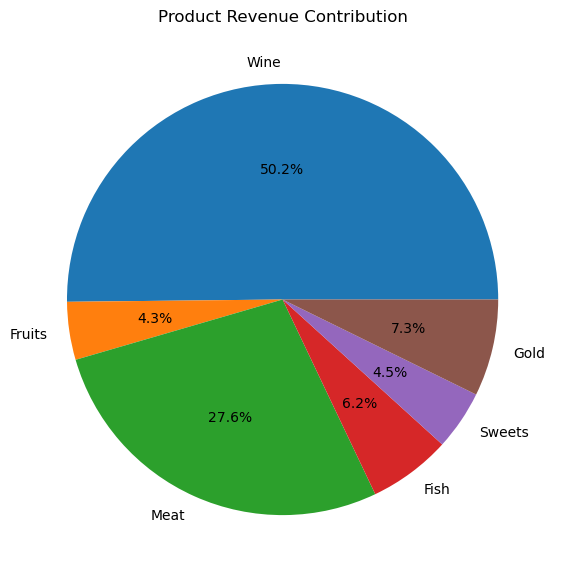

In [17]:
#Pie Chart
# Display product revenue contribution

plt.figure(figsize=(7,7))

plt.pie(product_df["Revenue"],
        labels=product_df["Product"],
        autopct="%1.1f%%")

plt.title("Product Revenue Contribution")

plt.show()

In [18]:
#Step 12: Purchase Behaviour Pattern
# Compare average online purchases across income levels

df.groupby("Customer_Segment")["NumWebPurchases"].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2251805895.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")["NumWebPurchases"].mean()


Customer_Segment
Low Value       2.653291
Medium Value    6.061497
High Value      5.325203
Name: NumWebPurchases, dtype: float64

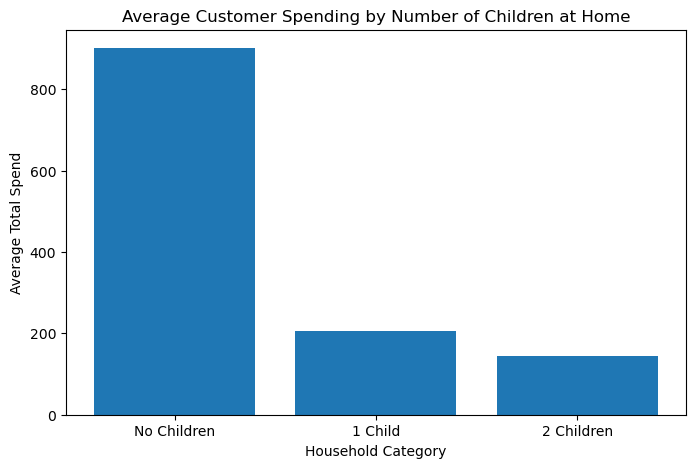

In [43]:
# Compare customer spending based on the number of children at home

kid_spend = (
    df.groupby("Kidhome")["Total_Spend"]
      .mean()
      .reset_index()
)

labels = {
    
    0: "No Children",
    1: "1 Child",
    2: "2 Children"
}

kid_spend["Kidhome"] = kid_spend["Kidhome"].map(labels)

plt.figure(figsize=(8,5))

plt.bar(
    kid_spend["Kidhome"],
    kid_spend["Total_Spend"]
)

plt.title("Average Customer Spending by Number of Children at Home")
plt.xlabel("Household Category")
plt.ylabel("Average Total Spend")

plt.show()

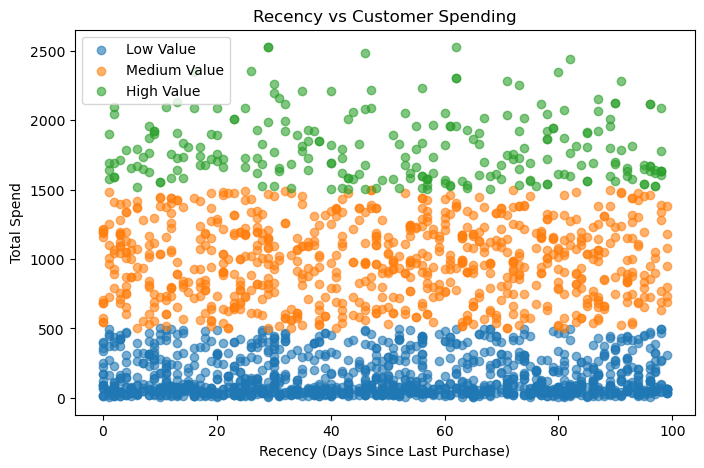

In [36]:
#Recency vs Spending (Much Better)
plt.figure(figsize=(8,5))

colors = {
    "Low Value": "red",
    "Medium Value": "orange",
    "High Value": "green"
}

for segment, color in colors.items():
    subset = df[df["Customer_Segment"] == segment]

    plt.scatter(
        subset["Recency"],
        subset["Total_Spend"],
        label=segment,
        alpha=0.6
    )

plt.title("Recency vs Customer Spending")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Total Spend")
plt.legend()

plt.show()

Recency means the number of days since the customer's last purchase.
So when we plot:

X-axis: Recency
Y-axis: Total Spend

we are  checking:

"Do customers who purchased recently spend more than customers who haven't purchased for a long time?"

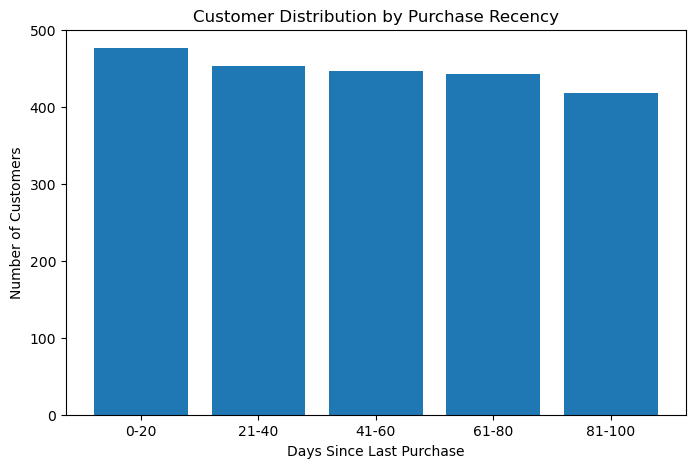

In [ ]:
#Customer Count by Recency Group :This shows how many customers fall into each recency bucket.
# Customer distribution across recency groups


# Create Recency Groups

df["Recency_Group"] = pd.cut(
    df["Recency"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"],
    include_lowest=True
)

customer_count = (
    df["Recency_Group"]
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    customer_count.index.astype(str),
    customer_count.values
)

plt.title("Customer Distribution by Purchase Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

#Insight:This helps identify whether most customers are active (recent buyers) or inactive (customers who haven't purchased recently).

In [20]:
#Step 13: Simple Predictive Analysis 
# Predict customer spending using income

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#Train a simple regression model with:
#Feature (X): Income
#Target (y): Total_Spend

In [26]:
#Step 14: Customer Response Analysis
#Analyze which customer groups are more likely to accept the marketing campaign.

# Calculate campaign response rate
response_rate = (
    df["Response"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

response_rate.index = ["Not Accepted", "Accepted"]


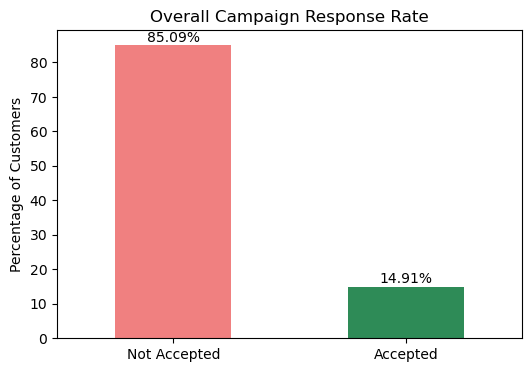

In [27]:

plt.figure(figsize=(6,4))

ax = response_rate.plot(
    kind="bar",
    color=["lightcoral", "seagreen"]
)

plt.ylabel("Percentage of Customers")
plt.title("Overall Campaign Response Rate")
plt.xticks(rotation=0)

for i, value in enumerate(response_rate):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

In [24]:
#Campaign Performance Analysis:Analyze the acceptance rate of each marketing campaign.
# Calculate campaign acceptance rate (%)

campaign_rates = (
    df[
        [
            "AcceptedCmp1",
            "AcceptedCmp2",
            "AcceptedCmp3",
            "AcceptedCmp4",
            "AcceptedCmp5"
        ]
    ]
    .mean() * 100
).round(2)

campaign_rates

AcceptedCmp1    6.43
AcceptedCmp2    1.34
AcceptedCmp3    7.28
AcceptedCmp4    7.46
AcceptedCmp5    7.28
dtype: float64

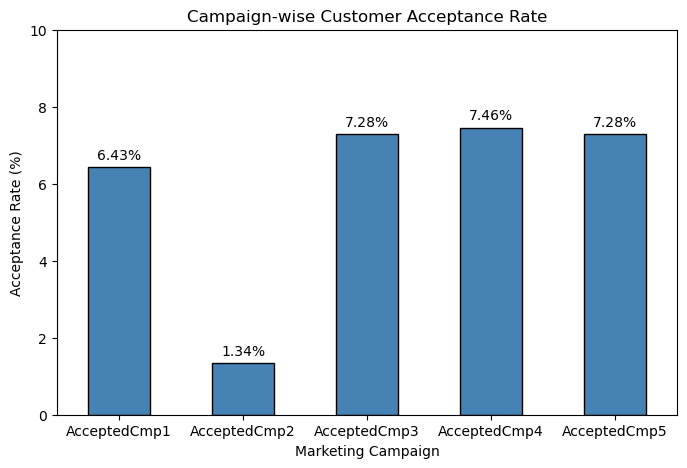

In [25]:
plt.figure(figsize=(8,5))

campaign_rates.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.ylabel("Acceptance Rate (%)")
plt.xlabel("Marketing Campaign")
plt.title("Campaign-wise Customer Acceptance Rate")

for i, value in enumerate(campaign_rates):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center", fontsize=10)

plt.xticks(rotation=0)
plt.ylim(0,10)

plt.show()

In [24]:
#Step 15: Customer Lifetime Value Indicators
# Compare average spending across customer segments

segment_summary = (
    df.groupby("Customer_Segment")
    [["Income","Total_Spend","Total_Purchases"]]
    .mean()
    .round(2)
)

segment_summary

C:\Users\Admin\AppData\Local\Temp\ipykernel_5912\923873560.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")


,Income,Total_Spend,Total_Purchases
Customer_Segment,,,
Low Value,38074.43,145.23,7.08
Medium Value,66828.73,980.48,19.20
High Value,79520.02,1799.34,19.96


c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


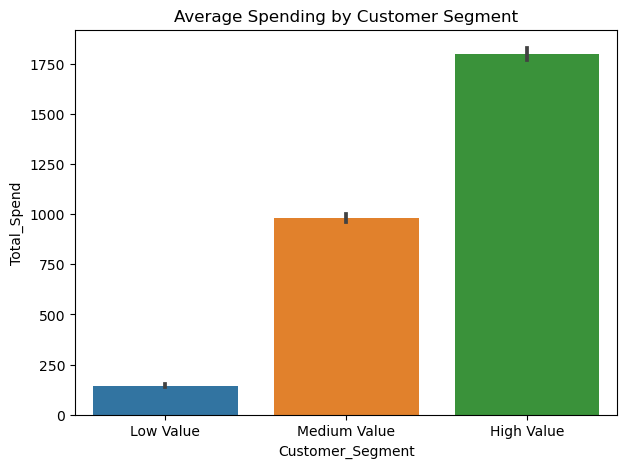

In [25]:
# Visualize average spending by customer segment

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Customer_Segment",
    y="Total_Spend"
)

plt.title("Average Spending by Customer Segment")

plt.show()

#Insight:High Value customers contribute the highest average spending and should be prioritized for premium offers and loyalty programs.

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\1558215685.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")["Response"]


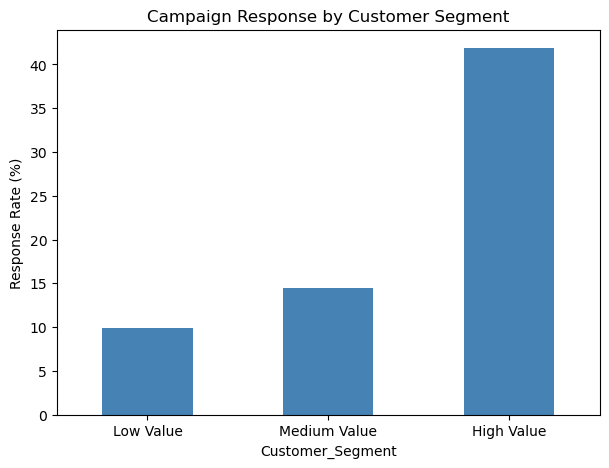

In [28]:
#Campaign Response by Customer Segment


segment_response = (
    df.groupby("Customer_Segment")["Response"]
      .mean()
      .mul(100)
      .round(2)
)

segment_response

#Visualization

plt.figure(figsize=(7,5))

segment_response.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Response Rate (%)")
plt.title("Campaign Response by Customer Segment")
plt.xticks(rotation=0)

plt.show()

#Business Insight: High Value customers respond more frequently. Premium campaigns should target High Value customers.

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2294168759.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Income_Group")["Response"]


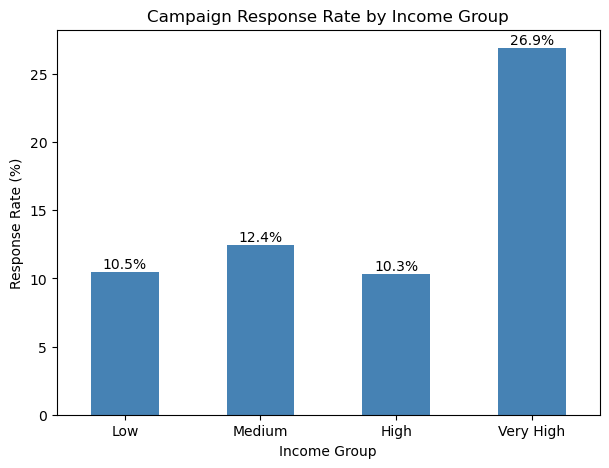

In [30]:
#Income vs Campaign Response 

df["Income_Group"] = pd.qcut(
    df["Income"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

income_response = (
    df.groupby("Income_Group")["Response"]
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7,5))

ax = income_response.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Campaign Response Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(income_response):
    plt.text(i, value+0.3, f"{value:.1f}%", ha="center")

plt.show()

#This Shows whether higher-income customers are more likely to accept campaigns.

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2738876324.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")[[


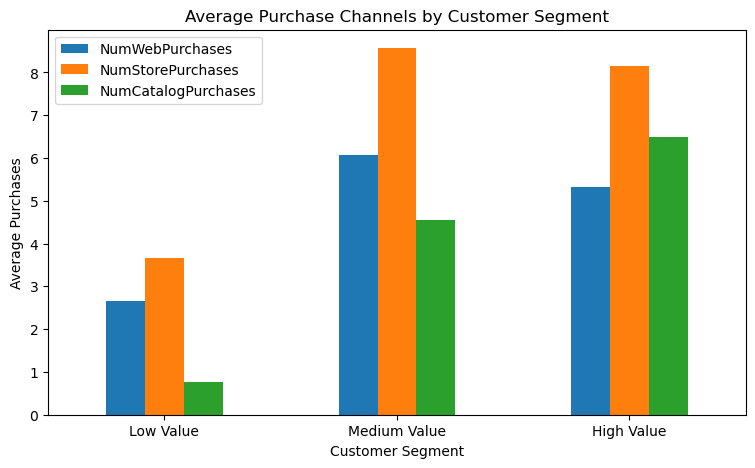

In [39]:
#Purchase Channel Preference by Customer Segment 

channel_segment = (
    df.groupby("Customer_Segment")[[
        "NumWebPurchases",
        "NumStorePurchases",
        "NumCatalogPurchases"
    ]]
    .mean()
)

channel_segment.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Purchase Channels by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchases")

plt.xticks(rotation=0)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9284\2519396979.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Segment")[[


<Figure size 1000x600 with 0 Axes>

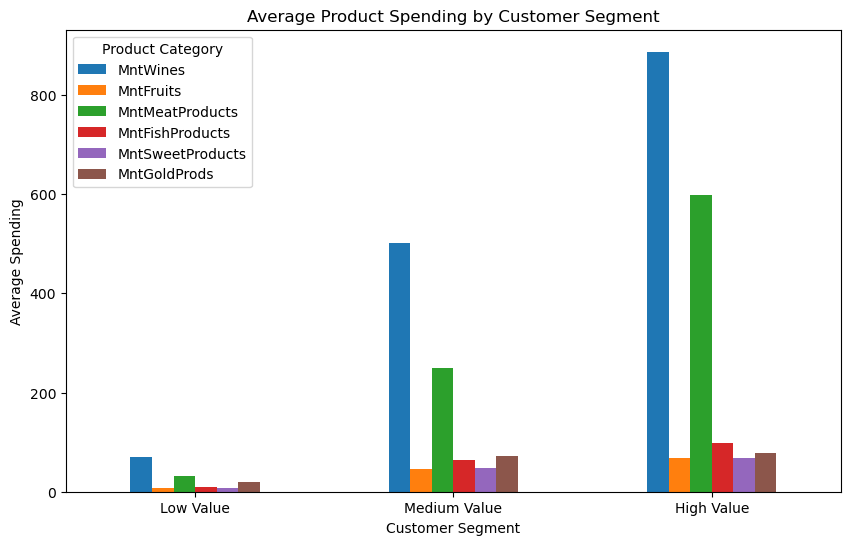

In [40]:
# Step 16: Product Preference Analysis
# Analyze average spending on different product categories by customer segment.

product_segment = (
    df.groupby("Customer_Segment")[[
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds"
    ]]
    .mean()
    .round(2)
)

product_segment

#Visualization
plt.figure(figsize=(10,6))

product_segment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Product Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")

plt.xticks(rotation=0)
plt.legend(title="Product Category")

plt.show()

#Business Insight:High Value customers consistently spend more across most product categories, particularly on Wines and Meat Products. Low Value customers contribute the least spending across all categories, suggesting opportunities for targeted promotions and personalized product recommendations.

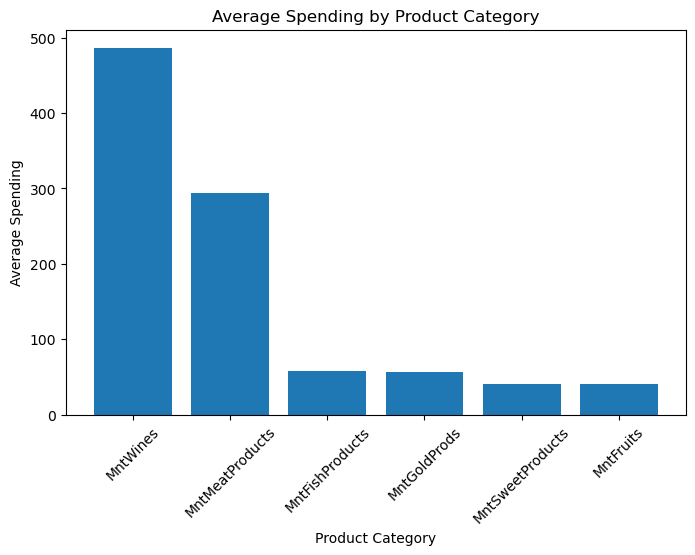

In [41]:
#Find the Most Popular Product Category
top_product = (
    product_segment.mean()
    .sort_values(ascending=False)
)

top_product

#Visualization
plt.figure(figsize=(8,5))

plt.bar(
    top_product.index,
    top_product.values
)

plt.title("Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Spending")

plt.xticks(rotation=45)

plt.show()




In [44]:
# Step 17: Export Processed Dataset for Tableau
# Export the final cleaned and feature-engineered dataset
df.to_csv("marketing_campaign_final.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


# Business Insights

1. High Value customers have the highest average income, spending, and purchase frequency, making them the company's most valuable customer segment.

2. Low Value customers represent the largest customer group but contribute the least to overall revenue, indicating an opportunity for targeted upselling.

3. Income shows a positive relationship with Total Spend, suggesting that higher-income customers are more likely to spend more.

4. Wine products generate the highest sales among all product categories, followed by Meat products.

5. Around 85% of customers did not respond to the marketing campaign, while only about 15% accepted the offer, indicating a low campaign response rate.

6. Several high-income outliers exist, representing premium customers who contribute significantly to revenue.

7. Medium Value customers make the highest average number of web purchases, showing strong engagement with the online sales channel.

8. Customers with frequent website visits do not always spend more, suggesting that website traffic alone does not guarantee conversions.

9. Customer segmentation clearly distinguishes spending behavior, helping businesses design targeted marketing strategies.

10. The overall analysis highlights opportunities to improve customer retention, campaign effectiveness, and revenue through data-driven decision making.